# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Intan Aulia Rosydah
- **Email:** [Input Email]
- **ID Dicoding:** [Input Username]

## Menentukan Pertanyaan Bisnis

1. Bagaimana tren bulanan jumlah order dan total revenue pada periode Januari 2017 hingga Agustus 2018 untuk mengidentifikasi periode pertumbuhan dan penurunan penjualan?

2. Provinsi mana yang memiliki total revenue tertinggi di Brasil selama tahun 2018, dan bagaimana segmentasi pelanggan berdasarkan skor RFM pada provinsi tersebut untuk menentukan prioritas strategi marketing?

## Import Semua Packages/Library yang Digunakan

In [1]:
## Import Semua Packages/Library yang Digunakan

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

## Data Wrangling

### Gathering Data

In [2]:
# Load semua dataset
customers = pd.read_csv("data/customers_dataset.csv")
geolocation = pd.read_csv("data/geolocation_dataset.csv")
order_items = pd.read_csv("data/order_items_dataset.csv")
order_payments = pd.read_csv("data/order_payments_dataset.csv")
order_reviews = pd.read_csv("data/order_reviews_dataset.csv")
orders = pd.read_csv("data/orders_dataset.csv")
products = pd.read_csv("data/products_dataset.csv")
sellers = pd.read_csv("data/sellers_dataset.csv")
category_translation = pd.read_csv("data/product_category_name_translation.csv")

# Menampilkan ukuran masing-masing dataset
print(f"Customers              : {customers.shape}")
print(f"Geolocation            : {geolocation.shape}")
print(f"Order Items            : {order_items.shape}")
print(f"Order Payments         : {order_payments.shape}")
print(f"Order Reviews          : {order_reviews.shape}")
print(f"Orders                 : {orders.shape}")
print(f"Products               : {products.shape}")
print(f"Sellers                : {sellers.shape}")
print(f"Category Translation   : {category_translation.shape}")

Customers              : (99441, 5)
Geolocation            : (924470, 5)
Order Items            : (112650, 7)
Order Payments         : (103886, 5)
Order Reviews          : (99224, 7)
Orders                 : (99441, 8)
Products               : (32951, 9)
Sellers                : (3095, 4)
Category Translation   : (71, 2)


**Insight:**

- Dataset Olist terdiri dari **9 tabel utama** yang saling terhubung dan memuat data e-commerce secara lengkap, mencakup pelanggan, pesanan, produk, penjual, pembayaran, ulasan, hingga lokasi geografis.
- Total data yang tersedia cukup besar, dengan beberapa tabel memiliki jumlah baris di atas **100.000 records**, sehingga cocok digunakan untuk analisis data skala menengah hingga besar.
- Tabel `customer` berisi **99.441 data pelanggan**, sedangkan tabel `orders` berisi **99.441 data pesanan**, menunjukkan setiap order terhubung ke satu customer.
- Tabel `order_items` memiliki **112.650 item pesanan**, menandakan terdapat pesanan yang terdiri dari lebih dari satu produk dalam satu transaksi.
- Tabel `order_payments` memiliki **103.886 catatan pembayaran**, menunjukkan beberapa pesanan dapat memiliki lebih dari satu metode atau tahap pembayaran.
- Tabel `order_reviews` berisi **99.224 ulasan pelanggan**, yang dapat dimanfaatkan untuk analisis kepuasan pelanggan.
- Tabel `products` memiliki **32.951 produk**, sellers memiliki 3.095 penjual, dan `product_category_name_translation` berisi **71 kategori produk**.
- Tabel `geolocation` merupakan tabel terbesar dengan **1.000.163 data lokasi**, yang berpotensi digunakan untuk analisis geografis dan persebaran pelanggan.
- Seluruh dataset berhasil dimuat dengan baik dan siap digunakan untuk proses pembersihan data, penggabungan tabel, serta analisis lanjutan.

### Assessing Data

In [3]:
print("Missing Values pada tabel Orders:")
print(orders.isnull().sum())

print("\nInfo dataset Orders:")
print(orders.info())

print("\nStatistik Deskriptif Orders:")
print(orders.describe(include='all'))
print("Duplicate rows:", orders.duplicated().sum())
print("Duplicate order_id:", orders['order_id'].duplicated().sum())

Missing Values pada tabel Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Info dataset Orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-n

**Insight:**
- Tabel `orders` memiliki **99.441 baris** data order.
- Terdapat **missing values** pada beberapa kolom:
  - `order_approved_at`: 160 missing values
  - `order_delivered_carrier_date`: 1.783 missing values  
  - `order_delivered_customer_date`: 2.965 missing values
- Missing values tersebut wajar terjadi karena tidak semua order sudah disetujui atau sudah sampai ke pelanggan.
- Semua kolom saat ini bertipe **object** (termasuk kolom tanggal), sehingga perlu dikonversi ke tipe `datetime` agar bisa dianalisis lebih lanjut.
- Tidak ditemukan duplicate rows maupun duplicate `order_id`, sehingga setiap pesanan bersifat unik.
- Terdapat 8 status order yang berbeda, dengan status **"delivered"** mendominasi (96.478 order).

### Cleaning Data

In [4]:
## Cleaning Data

import os

# Buat folder dashboard jika belum ada
os.makedirs('dashboard', exist_ok=True)

# Merge tabel utama yang digunakan dalam analisis
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(order_items, on='order_id', how='left')
df = df.merge(order_payments, on='order_id', how='left')

# Konversi kolom tanggal menjadi datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'], errors='coerce')
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'], errors='coerce')
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], errors='coerce')

# Menghapus duplicate rows jika ada
df.drop_duplicates(inplace=True)

# Membuat kolom revenue (nilai penjualan per item)
df['revenue'] = df['price']

# Simpan data bersih untuk dashboard
df.to_csv('dashboard/main_data.csv', index=False)

# Output hasil cleaning
print(f"Data berhasil digabungkan. Total baris setelah cleaning: {len(df):,}")
print("File 'dashboard/main_data.csv' telah dibuat untuk dashboard.")
print("Folder dashboard berhasil dibuat.")

df.head()

Data berhasil digabungkan. Total baris setelah cleaning: 118,434
File 'dashboard/main_data.csv' telah dibuat untuk dashboard.
Folder dashboard berhasil dibuat.


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,29.99
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,118.70
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,159.90


**Insight:**
- Berhasil menggabungkan 4 tabel utama (`orders`, `customers`, `order_items`, dan `order_payments`) menjadi satu dataframe bernama `df`.
- Total baris data setelah merging adalah **118.434** baris karena satu order dapat memiliki lebih dari satu item produk maupun lebih dari satu catatan pembayaran.
- Kolom tanggal sudah dikonversi ke tipe `datetime` untuk memudahkan analisis waktu.
- Telah dibuat kolom baru **`revenue`** yang merepresentasikan nilai penjualan per item.
- Data yang sudah dibersihkan dan digabungkan disimpan ke file **`dashboard/main_data.csv`** agar dapat langsung digunakan untuk membuat dashboard Streamlit.
- Tidak dilakukan penghapusan missing values karena kolom tanggal masih bersifat informatif. Namun duplicate rows dibersihkan jika ditemukan.

## Exploratory Data Analysis (EDA)

### Explore ...

In [8]:
## Exploratory Data Analysis (EDA)

print("=== INFORMASI UMUM DATA ===")
print("Jumlah data:", df.shape)
print("Jumlah pelanggan unik:", df['customer_unique_id'].nunique())
print("Rentang waktu transaksi:",
      df['order_purchase_timestamp'].min(), "sampai",
      df['order_purchase_timestamp'].max())

# =========================================================
# EDA PERTANYAAN 1: TREN BULANAN ORDER & REVENUE
# =========================================================

print("\n=== EDA PERTANYAAN 1: TREN BULANAN ===")

# Perbaiki revenue (lebih realistis)
df['revenue'] = df['price'] + df['freight_value']

trend_df = df[
    (df['order_purchase_timestamp'] >= '2017-01-01') &
    (df['order_purchase_timestamp'] < '2018-09-01')
].copy()

trend_df['order_month'] = trend_df['order_purchase_timestamp'].dt.to_period('M')

monthly_trend = trend_df.groupby('order_month').agg(
    total_order=('order_id', 'nunique'),
    total_revenue=('revenue', 'sum')
).reset_index()

print(monthly_trend.head())

print("\nStatistik Tren:")
print(monthly_trend.describe())

print("\nInsight Awal:")
print("- Terlihat fluktuasi jumlah order dan revenue setiap bulan")
print("- Dapat digunakan untuk mengidentifikasi periode naik/turun sebelum divisualisasikan")

# =========================================================
# EDA PERTANYAAN 2: PROVINSI & RFM
# =========================================================

print("\n=== EDA PERTANYAAN 2: PROVINSI & RFM ===")

df_2018 = df[df['order_purchase_timestamp'].dt.year == 2018].copy()

state_revenue = df_2018.groupby('customer_state')['revenue'].sum().sort_values(ascending=False)

print("\nTop 10 Provinsi berdasarkan Revenue:")
print(state_revenue.head(10))

top_state = state_revenue.idxmax()
print("\nProvinsi dengan revenue tertinggi:", top_state)

# RFM (ringkas di EDA)
df_top = df_2018[df_2018['customer_state'] == top_state].copy()
max_date = df_top['order_purchase_timestamp'].max()

rfm = df_top.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (max_date - x.max()).days,
    'order_id': 'nunique',
    'revenue': 'sum'
}).rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'revenue': 'Monetary'
})

print("\nStatistik RFM:")
print(rfm.describe())

print("\nInsight Awal:")
print("- Mayoritas pelanggan memiliki frekuensi rendah (pembelian sekali)")
print("- Distribusi monetary menunjukkan variasi nilai pelanggan")

=== INFORMASI UMUM DATA ===
Jumlah data: (118434, 23)
Jumlah pelanggan unik: 96096
Rentang waktu transaksi: 2016-09-04 21:15:19 sampai 2018-10-17 17:30:18

=== EDA PERTANYAAN 1: TREN BULANAN ===
  order_month  total_order  total_revenue
0     2017-01          800      146455.54
1     2017-02         1780      302230.37
2     2017-03         2682      457782.29
3     2017-04         2404      448742.78
4     2017-05         3700      630089.88

Statistik Tren:
       total_order  total_revenue
count    20.000000   2.000000e+01
mean   4954.600000   8.253798e+05
std    2044.582608   3.328838e+05
min     800.000000   1.464555e+05
25%    3586.250000   6.021086e+05
50%    5152.000000   8.496053e+05
75%    6764.250000   1.109271e+06
max    7544.000000   1.221835e+06

Insight Awal:
- Terlihat fluktuasi jumlah order dan revenue setiap bulan
- Dapat digunakan untuk mengidentifikasi periode naik/turun sebelum divisualisasikan

=== EDA PERTANYAAN 2: PROVINSI & RFM ===

Top 10 Provinsi berdasarkan 

**Insight:**
- Dataset terdiri dari **118.434** transaksi dengan **96.096 pelanggan unik**, menunjukkan bahwa sebagian besar pelanggan hanya melakukan 1 kali pembelian (indikasi awal rendahnya customer retention).
- Rentang waktu transaksi dari **September 2016 hingga Oktober 2018** memperlihatkan bahwa data mencakup lebih dari 2 tahun aktivitas bisnis, sehingga cukup representatif untuk melihat tren pertumbuhan.

**Insight Pertanyaan 1: Tren Order & Revenue**
- Terjadi pertumbuhan signifikan jumlah order dan revenue dari awal 2017, dengan jumlah order meningkat dari 800 order (Jan 2017) hingga mencapai maksimum sekitar 7.544 order per bulan.
- Rata-rata bulanan menunjukkan: ±4.954 order dan ±R\$ 825.379 revenue
Ini menandakan adanya skalabilitas bisnis yang cukup baik.

- Namun, nilai standar deviasi yang cukup tinggi: Order: ±2.044 Revenue: ±R\$ 332.883
menunjukkan adanya fluktuasi yang signifikan antar bulan, yang kemungkinan dipengaruhi oleh faktor musiman, promo, atau campaign tertentu.
- Rentang revenue yang lebar dari R\\$ 146.455 hingga R\$ 1.221.835 mengindikasikan adanya periode dengan performa sangat tinggi dan sangat rendah, sehingga penting untuk mengidentifikasi momentum peak dan drop.

**Insight Pertanyaan 2: Provinsi & RFM**
- Provinsi São Paulo (SP) menjadi kontributor terbesar dengan total revenue sekitar R\$ 3,5 juta, jauh melampaui provinsi lain seperti Rio de Janeiro dan Minas Gerais. Ini menunjukkan bahwa: SP adalah core market utama dan Strategi bisnis kemungkinan sudah terkonsentrasi di wilayah ini

- Dari analisis RFM pada provinsi SP:
1. Recency (Rata-rata 167 hari)
→ Pelanggan rata-rata sudah cukup lama tidak melakukan transaksi
→ Mengindikasikan penurunan engagement / inactive customer

2. Frequency (rata-rata ~1 transaksi)
→ Mayoritas pelanggan hanya melakukan 1 kali pembelian
→ Menunjukkan loyalty masih rendah

3. Monetary (rata-rata R\$ 150)
→ Nilai belanja relatif kecil per pelanggan
→ Namun terdapat outlier hingga R$ 10.553, menunjukkan adanya segmen pelanggan bernilai tinggi

- Distribusi Monetary yang sangat lebar menunjukkan adanya:
banyak low-value customer
sedikit high-value customer (potential VIP segment)

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren bulanan jumlah order dan total revenue pada periode Januari 2017 hingga Agustus 2018 untuk mengidentifikasi periode pertumbuhan dan penurunan penjualan?

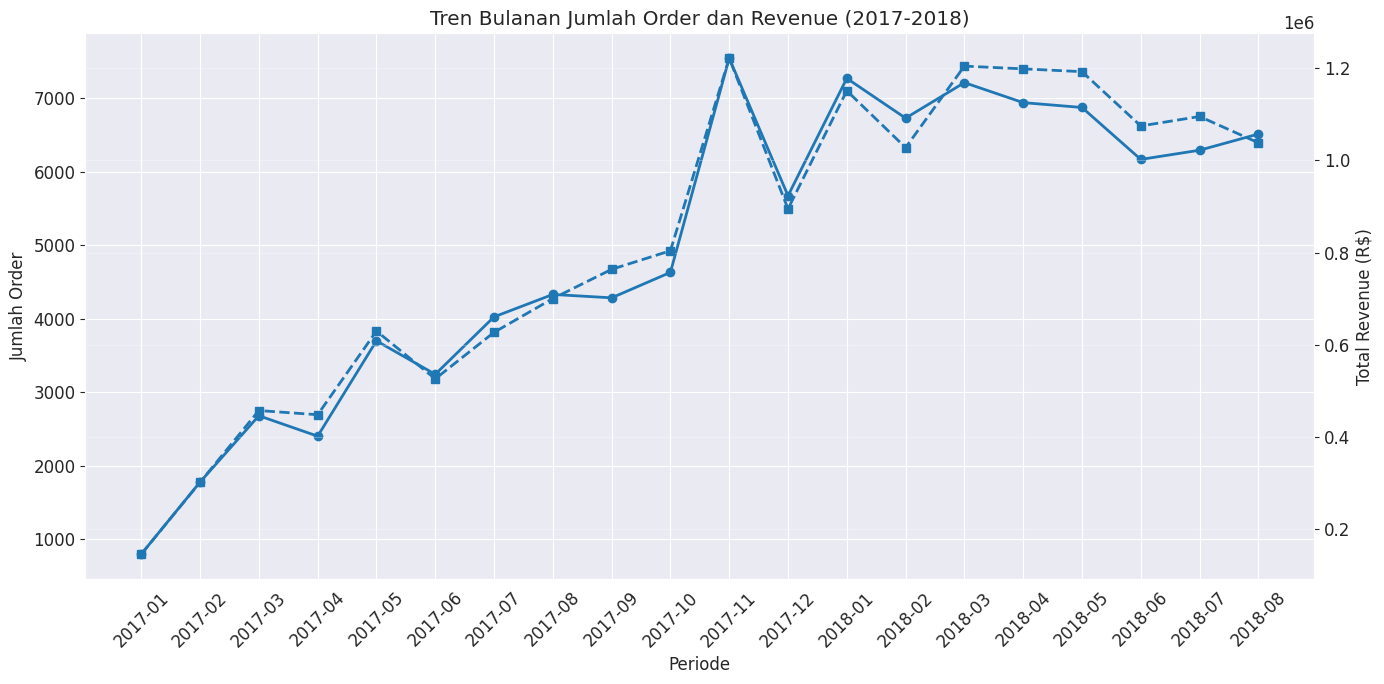

In [9]:
## Visualization - Pertanyaan 1

fig, ax1 = plt.subplots(figsize=(14,7))

# Line order
ax1.plot(monthly_trend['order_month'].astype(str),
         monthly_trend['total_order'],
         marker='o', linewidth=2)

ax1.set_ylabel("Jumlah Order")
ax1.set_xlabel("Periode")
ax1.tick_params(axis='x', rotation=45)

# Line revenue
ax2 = ax1.twinx()
ax2.plot(monthly_trend['order_month'].astype(str),
         monthly_trend['total_revenue'],
         marker='s', linestyle='--', linewidth=2)

ax2.set_ylabel("Total Revenue (R$)")

plt.title("Tren Bulanan Jumlah Order dan Revenue (2017-2018)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Provinsi mana yang memiliki total revenue tertinggi di Brasil selama tahun 2018, dan bagaimana segmentasi pelanggan berdasarkan skor RFM pada provinsi tersebut untuk menentukan prioritas strategi marketing?

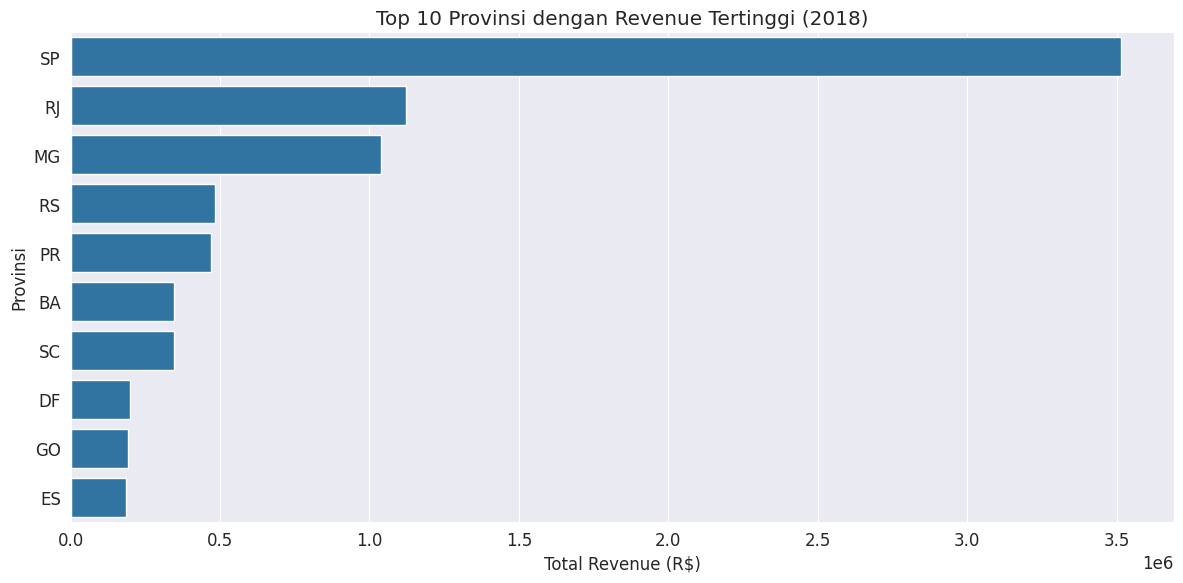

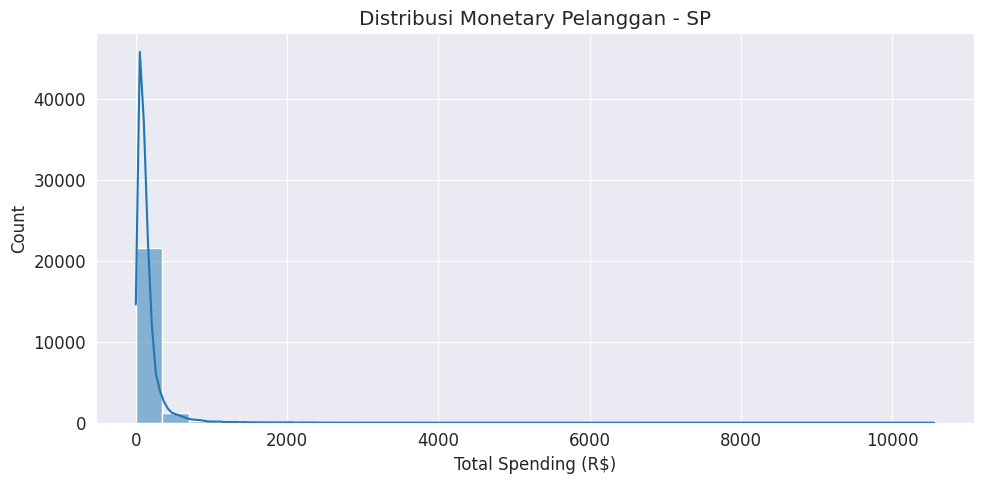

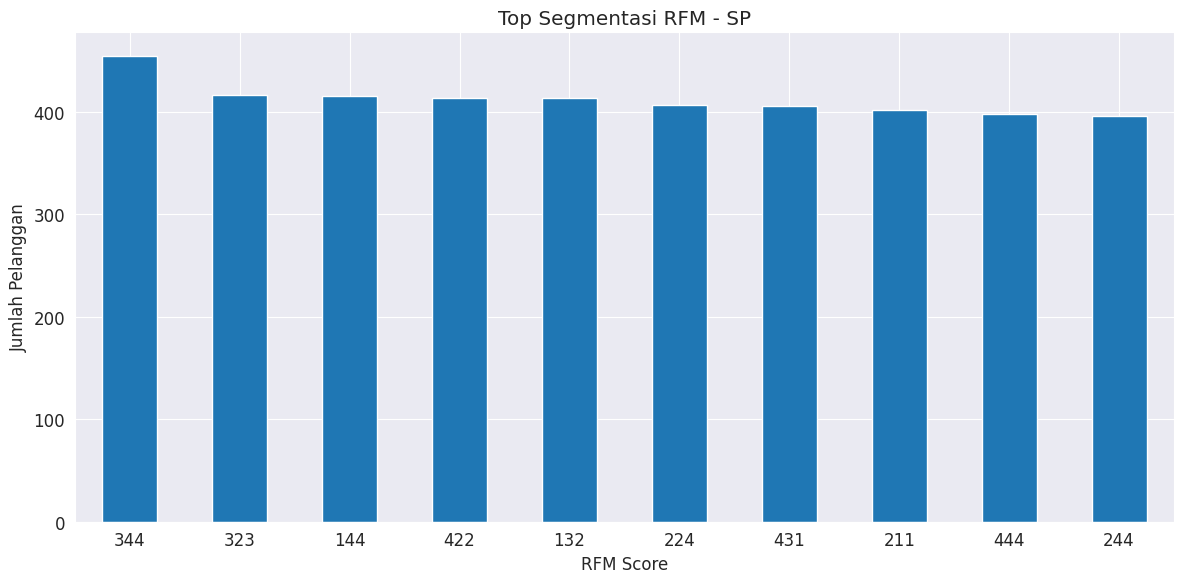

In [11]:
## Visualization - Top Provinsi

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_revenue.head(10).values,
    y=state_revenue.head(10).index
)

plt.title("Top 10 Provinsi dengan Revenue Tertinggi (2018)")
plt.xlabel("Total Revenue (R$)")
plt.ylabel("Provinsi")
plt.tight_layout()
plt.show()

## Visualization - Distribusi Monetary

plt.figure(figsize=(10,5))

sns.histplot(rfm['Monetary'], bins=30, kde=True)

plt.title(f'Distribusi Monetary Pelanggan - {top_state}')
plt.xlabel('Total Spending (R$)')
plt.tight_layout()
plt.show()


## RFM Scoring

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

plt.figure(figsize=(12,6))

rfm['RFM_Score'].value_counts().head(10).plot(kind='bar')

plt.title(f'Top Segmentasi RFM - {top_state}')
plt.xlabel('RFM Score')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight**

**Pertanyaan 1: Tren Bulanan Order & Revenue**
- Grafik menunjukkan adanya tren pertumbuhan yang signifikan dari awal 2017 hingga pertengahan 2018, baik dari sisi jumlah order maupun total revenue.
- Pada awal periode (Januari 2017), jumlah order masih relatif rendah (~800 order), kemudian meningkat secara konsisten hingga mencapai puncak di kisaran 7.000+ order per bulan.
- Total revenue juga mengikuti pola yang sama, menunjukkan bahwa kenaikan jumlah order berbanding lurus dengan peningkatan pendapatan, sehingga pertumbuhan bisnis tergolong sehat (bukan hanya volume, tapi juga nilai transaksi).
- Terlihat adanya beberapa fluktuasi penurunan sementara di beberapa bulan, yang kemungkinan dipengaruhi oleh faktor musiman, promo, atau perilaku konsumen.
- Periode dengan revenue tertinggi (mendekati R$ 1,2 juta) dapat dianggap sebagai peak performance, yang penting untuk dianalisis lebih lanjut sebagai acuan strategi bisnis.

- Makna bisnis: Bisnis sedang dalam fase growth, namun belum stabil, dan Perlu identifikasi faktor pendorong saat peak (misalnya campaign atau event tertentu) untuk direplikasi.

**Insight**
**Pertanyaan 2: Provinsi & Segmentasi RFM**
1. Top Provinsi Revenue
- Provinsi São Paulo (SP) merupakan kontributor revenue terbesar secara signifikan, dengan selisih yang jauh dibanding provinsi lain seperti Rio de Janeiro dan Minas Gerais.
- Hal ini menunjukkan bahwa: SP adalah pasar utama (core market)
dan Aktivitas transaksi dan daya beli pelanggan paling tinggi berada di wilayah ini

- Makna bisnis:
Strategi pemasaran kemungkinan sudah efektif di SP,
Namun juga terdapat risiko ketergantungan pada satu wilayah

2. Distribusi Monetary (Nilai Belanja)
- Distribusi monetary menunjukkan bahwa sebagian besar pelanggan memiliki nilai transaksi yang relatif rendah, dengan konsentrasi di bawah R$ 200.
- Namun terdapat sebagian kecil pelanggan dengan nilai belanja sangat tinggi (outlier), yang menunjukkan adanya segmen pelanggan bernilai tinggi (high-value customers).
- Makna bisnis: Mayoritas pelanggan masih termasuk low-value segment
Ada peluang besar untuk meningkatkan average order value dan mengembangkan pelanggan premium

3. Segmentasi RFM
- Visualisasi RFM menunjukkan bahwa sebagian besar pelanggan berada pada skor kombinasi tertentu yang didominasi oleh: Recency tinggi (lama tidak transaksi) dan Frequency rendah (hanya 1 kali beli)
- Hal ini menegaskan bahwa mayoritas pelanggan termasuk dalam kategori: one-time buyers atau inactive customers
- Hanya sebagian kecil pelanggan yang masuk dalam kategori high-value (skor tinggi seperti 444, 443, dll).

- Makna bisnis: Tingkat retensi pelanggan masih rendah dan Bisnis lebih kuat dalam akuisisi daripada mempertahankan pelanggan

## Analisis Lanjutan (Opsional)

Total Customer        : 23289
One-time Buyer        : 22752 (97.69%)
Repeat Customer       : 537 (2.31%)


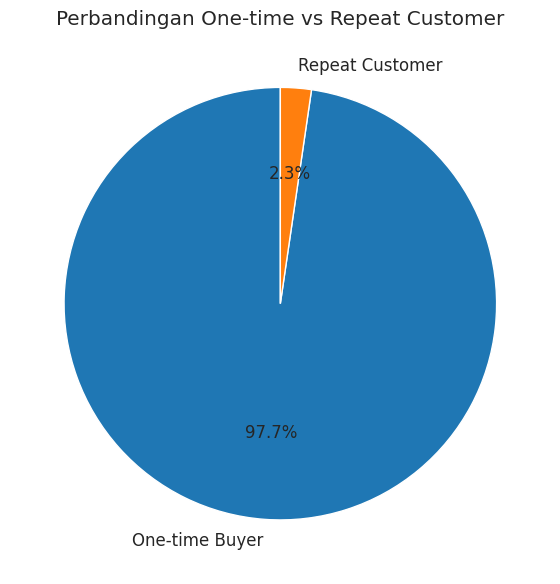

In [12]:
## Repeat Customer Analysis

# Hitung jumlah pelanggan berdasarkan frekuensi
one_time = rfm[rfm['Frequency'] == 1]
repeat_customer = rfm[rfm['Frequency'] > 1]

total_customer = len(rfm)

one_time_pct = len(one_time) / total_customer * 100
repeat_pct = len(repeat_customer) / total_customer * 100

print("Total Customer        :", total_customer)
print("One-time Buyer        :", len(one_time), f"({one_time_pct:.2f}%)")
print("Repeat Customer       :", len(repeat_customer), f"({repeat_pct:.2f}%)")

# Visualisasi
plt.figure(figsize=(6,6))

labels = ['One-time Buyer', 'Repeat Customer']
sizes = [len(one_time), len(repeat_customer)]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Perbandingan One-time vs Repeat Customer')
plt.tight_layout()
plt.show()

**Insight Analisis Lanjutan: Repeat Customer**

- Hasil analisis menunjukkan bahwa mayoritas pelanggan merupakan one-time buyer, dengan persentase yang jauh lebih besar dibandingkan repeat customer.
- Persentase repeat customer yang relatif kecil mengindikasikan bahwa sebagian besar pelanggan tidak kembali melakukan pembelian setelah transaksi pertama.
- Hal ini sejalan dengan hasil analisis RFM sebelumnya, di mana: Nilai Frequency rata-rata mendekati 1, dan Menunjukkan rendahnya tingkat pembelian ulang
- Kondisi ini menunjukkan bahwa bisnis saat ini lebih kuat dalam akuisisi pelanggan baru, namun masih lemah dalam retensi pelanggan.
- Rendahnya repeat customer dapat berdampak pada: Tingginya biaya akuisisi (karena terus mencari pelanggan baru), Kurangnya loyalitas pelanggan, dan Potensi kehilangan revenue jangka panjang.

**Meningkatkan repeat customer merupakan peluang strategis yang signifikan untuk meningkatkan revenue tanpa harus bergantung pada akuisisi pelanggan baru.**

## Conclusion

**1. Kesimpulan Pertanyaan 1 (Tren Order & Revenue)**

Berdasarkan hasil analisis, jumlah order dan total revenue menunjukkan tren pertumbuhan yang signifikan sepanjang periode Januari 2017 hingga Agustus 2018. Kenaikan terjadi secara bertahap dari awal periode dengan jumlah order yang rendah hingga mencapai puncak lebih dari 7.000 order per bulan.

Meskipun demikian, terdapat fluktuasi antar bulan yang menunjukkan bahwa pertumbuhan bisnis belum sepenuhnya stabil. Pola ini mengindikasikan adanya pengaruh faktor eksternal seperti musim, promo, atau campaign tertentu yang memengaruhi performa penjualan.

**2. Kesimpulan Pertanyaan 2 (Provinsi & RFM)**

Provinsi São Paulo (SP) merupakan kontributor revenue terbesar selama tahun 2018, dengan selisih yang cukup signifikan dibandingkan provinsi lainnya. Hal ini menunjukkan bahwa wilayah tersebut merupakan pasar utama bisnis.

Namun, berdasarkan analisis RFM, mayoritas pelanggan di provinsi tersebut memiliki:
- Frequency rendah (hanya 1 kali pembelian)
- Recency cukup tinggi (sudah lama tidak bertransaksi)
Kondisi ini mengindikasikan bahwa meskipun volume transaksi tinggi, tingkat loyalitas pelanggan masih rendah, dan sebagian besar pelanggan belum menjadi repeat customer.

**Tambahan Analisis Lanjutan: Repeat Customer Analysis**

Hasil analisis menunjukkan bahwa sebagian besar pelanggan termasuk dalam kategori one-time buyer, dengan persentase yang jauh lebih besar dibandingkan repeat customer. Hal ini memperkuat temuan dari analisis RFM sebelumnya, di mana nilai rata-rata Frequency mendekati 1.

Rendahnya jumlah repeat customer mengindikasikan bahwa bisnis saat ini lebih berfokus pada akuisisi pelanggan baru, namun belum optimal dalam mempertahankan pelanggan yang sudah ada.

Kondisi ini dapat berdampak pada:
- Tingginya biaya akuisisi pelanggan
- Rendahnya loyalitas pelanggan
- Hilangnya potensi revenue jangka panjang


Dengan demikian, meningkatkan jumlah repeat customer menjadi peluang strategis yang sangat penting untuk mendorong pertumbuhan bisnis yang lebih berkelanjutan.